In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from scipy.stats import ks_2samp
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from catboost import CatBoostClassifier
from scipy.stats import ks_2samp
import h2o
from h2o.automl import H2OAutoML
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve



file_path = os.path.join('..', 'Data', 'processed', 'Data.pkl')
Data = pd.read_pickle(file_path)

In [2]:
X = Data.drop(columns=['target'])
y = Data['target']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [3]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val)

callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=True)]

model_lgb = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    num_boost_round=1000,
    callbacks=callbacks
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[32]	valid_0's auc: 0.641267


In [4]:
y_pred_proba = model_lgb.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)
ks_stat = ks_2samp(y_pred_proba[y_test == 1], y_pred_proba[y_test == 0]).statistic

print(f"ROC AUC: {roc_auc:.4f}, Accuracy: {accuracy:.4f}, KS: {ks_stat:.4f}")

ROC AUC: 0.6762, Accuracy: 0.9711, KS: 0.2876


-------------

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

y_train = y_train.values.ravel() if isinstance(y_train, pd.Series) else y_train.ravel()
y_val = y_val.values.ravel() if isinstance(y_val, pd.Series) else y_val.ravel()
y_test = y_test.values.ravel() if isinstance(y_test, pd.Series) else y_test.ravel()

unique_classes = np.unique(y_train)
print("Clases únicas en y_train:", unique_classes)
print("Tipo de datos en y_train:", y_train.dtype)

class_weights = compute_class_weight(
    'balanced', 
    classes=unique_classes,  
    y=y_train
)

class_weights_dict = {int(cls): weight for cls, weight in zip(unique_classes, class_weights)}
print("Pesos de las clases ajustados:", class_weights_dict)

model_nn = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),  
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_nn.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='binary_crossentropy', 
    metrics=['AUC']
)

history = model_nn.fit(
    X_train_scaled, 
    y_train, 
    validation_data=(X_val_scaled, y_val), 
    epochs=50, 
    batch_size=32, 
    class_weight=class_weights_dict, 
    verbose=1
)

Clases únicas en y_train: [0. 1.]
Tipo de datos en y_train: float64
Pesos de las clases ajustados: {0: 0.5149062228763349, 1: 17.27151898734177}
Epoch 1/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.5419 - loss: 0.7581 - val_AUC: 0.6318 - val_loss: 0.6460
Epoch 2/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.6042 - loss: 0.6758 - val_AUC: 0.6654 - val_loss: 0.6817
Epoch 3/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.6421 - loss: 0.6621 - val_AUC: 0.6526 - val_loss: 0.6669
Epoch 4/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - AUC: 0.6593 - loss: 0.6627 - val_AUC: 0.6659 - val_loss: 0.6738
Epoch 5/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - AUC: 0.6648 - loss: 0.6560 - val_AUC: 0.6708 - val_loss: 0.6106
Epoch 6/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.6740 - loss: 0.6295 - val_AUC: 0.6814 - val_loss: 0.6262
Epoch 7/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - AUC: 0.6939 - loss: 0.6454 - val_AUC: 0.6601 - val_loss: 0.5858
Epoch 8/50
853/853 ━━━━━━━━━━

In [22]:
y_pred_proba_nn = model_nn.predict(X_test_scaled).flatten()
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)

roc_auc_nn = roc_auc_score(y_test, y_pred_proba_nn)
accuracy_nn = accuracy_score(y_test, y_pred_nn)
ks_stat_nn = ks_2samp(y_pred_proba_nn[y_test == 1], y_pred_proba_nn[y_test == 0]).statistic

print(f"ROC AUC (NN): {roc_auc_nn:.4f}, Accuracy (NN): {accuracy_nn:.4f}, KS (NN): {ks_stat_nn:.4f}")

183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
ROC AUC (NN): 0.6167, Accuracy (NN): 0.7095, KS (NN): 0.2022


0:	test: 0.5561547	best: 0.5561547 (0)	total: 58.9ms	remaining: 58.9s
100:	test: 0.6272023	best: 0.6308866 (37)	total: 4.9s	remaining: 43.6s
200:	test: 0.6252142	best: 0.6362046 (115)	total: 9.01s	remaining: 35.8s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6362045989
bestIteration = 115

Shrink model to first 116 iterations.
CatBoost - ROC AUC: 0.6177, Accuracy: 0.8365, KS: 0.1863
CatBoost - Precision: 0.0523, Recall: 0.2722, F1: 0.0878


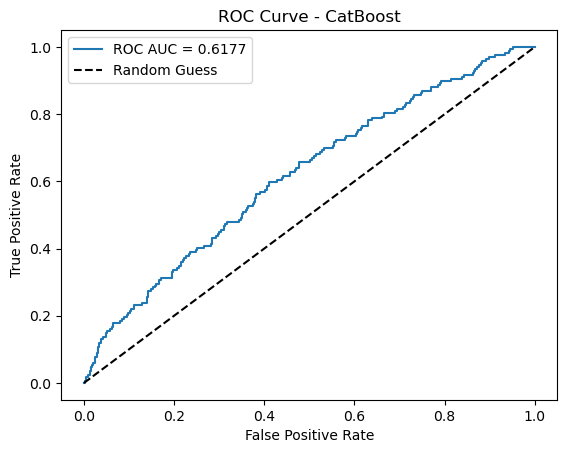

In [30]:
model_catboost = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,  
    depth=8,          
    loss_function='Logloss',
    eval_metric='AUC',
    auto_class_weights='Balanced',  
    verbose=100,
    random_state=42
)

model_catboost.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=100  
)

y_pred_proba_catboost = model_catboost.predict_proba(X_test)[:, 1]
y_pred_catboost = (y_pred_proba_catboost > 0.5).astype(int)

roc_auc_catboost = roc_auc_score(y_test, y_pred_proba_catboost)
accuracy_catboost = accuracy_score(y_test, y_pred_catboost)
ks_stat_catboost = ks_2samp(y_pred_proba_catboost[y_test == 1], y_pred_proba_catboost[y_test == 0]).statistic
precision_catboost = precision_score(y_test, y_pred_catboost)
recall_catboost = recall_score(y_test, y_pred_catboost)
f1_catboost = f1_score(y_test, y_pred_catboost)

print(f"CatBoost - ROC AUC: {roc_auc_catboost:.4f}, Accuracy: {accuracy_catboost:.4f}, KS: {ks_stat_catboost:.4f}")
print(f"CatBoost - Precision: {precision_catboost:.4f}, Recall: {recall_catboost:.4f}, F1: {f1_catboost:.4f}")


In [34]:
if isinstance(y_train, np.ndarray):
    y_train = pd.Series(y_train, name='target')
if isinstance(y_val, np.ndarray):
    y_val = pd.Series(y_val, name='target')
if isinstance(y_test, np.ndarray):
    y_test = pd.Series(y_test, name='target')

h2o.init()

train_h2o = h2o.H2OFrame(pd.concat([X_train, y_train], axis=1))
val_h2o = h2o.H2OFrame(pd.concat([X_val, y_val], axis=1))
test_h2o = h2o.H2OFrame(pd.concat([X_test, y_test], axis=1))

# Configurar columnas
features = list(X.columns)
target = 'target'

# Entrenamiento de AutoML
aml = H2OAutoML(max_models=10, seed=42, stopping_metric='AUC', sort_metric='AUC')
aml.train(x=features, y=target, training_frame=train_h2o, validation_frame=val_h2o)

# Mejor modelo
best_model = aml.leader

# Evaluación
predictions = best_model.predict(test_h2o)
y_pred_proba_automl = predictions.as_data_frame()['p1'].values
y_pred_automl = (y_pred_proba_automl > 0.5).astype(int)

roc_auc_automl = roc_auc_score(y_test, y_pred_proba_automl)
accuracy_automl = accuracy_score(y_test, y_pred_automl)
ks_stat_automl = ks_2samp(y_pred_proba_automl[y_test == 1], y_pred_proba_automl[y_test == 0]).statistic

print(f"AutoML (H2O) - ROC AUC: {roc_auc_automl:.4f}, Accuracy: {accuracy_automl:.4f}, KS: {ks_stat_automl:.4f}")

# Apagar H2O
h2o.shutdown()

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,9 mins 17 secs
H2O_cluster_timezone:,America/Mexico_City
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.6
H2O_cluster_version_age:,4 months and 24 days
H2O_cluster_name:,H2O_from_python_Usuario_j000p9
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.896 Gb
H2O_cluster_total_cores:,4
H2O_cluster_allowed_cores:,4
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%

21:49:49.92: User specified a validation frame with cross-validation still enabled. Please note that the models will still be validated using cross-validation only, the validation frame will be used to provide purely informative validation metrics on the trained models.
21:49:49.109: AutoML: XGBoost is not available; skipping it.
21:49:49.362: _response param, We have detected that your response column has only 2 unique values (0/1). If you wish to train a binary model instead of a regression model, convert your target column to categorical before training.
21:49:49.362: _validation_frame param, Test/Validation 

AttributeError: 'NoneType' object has no attribute 'predict'

In [32]:
print("Tipo de X_train:", type(X_train))
print("Tipo de y_train:", type(y_train))
print("Tipo de X_val:", type(X_val))
print("Tipo de y_val:", type(y_val))
print("Tipo de X_test:", type(X_test))
print("Tipo de y_test:", type(y_test))

Tipo de X_train: <class 'pandas.core.frame.DataFrame'>
Tipo de y_train: <class 'numpy.ndarray'>
Tipo de X_val: <class 'pandas.core.frame.DataFrame'>
Tipo de y_val: <class 'numpy.ndarray'>
Tipo de X_test: <class 'pandas.core.frame.DataFrame'>
Tipo de y_test: <class 'numpy.ndarray'>
